# Predicting Rock Density from Well Log Data Using Machine Learning

1. Introduction
2. Data Loading
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Selection
6. Model Development
7. Model Evaluation
8. Results & Interpretation
9. Conclusion

In [1]:
import pandas as pd
import numpy as np
import lasio as ls
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import ipywidgets as widgets
from IPython.display import display

In [2]:
las = ls.read('datasets/Data2.las')
las_df = las.df().reset_index()
las_df.replace(las.well.NULL.value, np.nan, inplace=True)

print(las_df.columns)

Index(['DEPT', 'CALI', 'DT', 'GR', 'RESD', 'LLS', 'NPHI', 'RHOB'], dtype='object')


In [3]:
las_df.describe()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB
count,23064.00000,23021.000000,15309.000000,23064.000000,15309.000000,15309.000000,15309.000000,15181.000000
mean,5775.75000,16.735029,114.785571,42.331518,30.637322,5.782516,0.226503,2.182348
std,3329.07382,3.845561,26.251967,26.903011,50.863012,12.707649,0.957280,0.152106
min,10.00000,5.723400,13.900001,0.600000,0.053700,0.091400,-9.992500,1.266900
25%,2892.87500,12.727201,97.900002,19.365000,1.744100,1.800200,0.271100,2.142600
50%,5775.75000,17.199999,110.599998,37.418850,5.521200,3.529800,0.316100,2.196800
75%,8658.62500,19.799999,121.399994,55.589650,44.506100,6.457200,0.369200,2.254300
max,11541.50000,22.777199,260.700012,142.199493,1213.057373,341.103912,0.626800,2.671600


In [4]:
print(las_df.isna().sum())

DEPT       0
CALI      43
DT      7755
GR         0
RESD    7755
LLS     7755
NPHI    7755
RHOB    7883
dtype: int64


In [5]:
ranges = {
    "CALI": (6, 20),
    "DT": (40, 240),
    "GR": (0, 150),
    "RESD": (0.2, 2000),
    "LLS": (0.2, 2000),
    "NPHI": (-0.15, 0.45),
    "RHOB": (1.95, 2.95),
}


working_df = las_df.copy()

for col, (min_val, max_val) in ranges.items():
    if col in working_df.columns:
        outliers = ~working_df[col].between(min_val, max_val)
        print(col,"out of range", int(outliers.sum()))
        working_df.loc[outliers, col] = np.nan

CALI out of range 5458
DT out of range 7790
GR out of range 0
RESD out of range 7837
LLS out of range 7831
NPHI out of range 8994
RHOB out of range 8656


In [6]:
working_df.head()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB
0,10.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
1,10.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
2,11.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
3,11.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
4,12.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN


In [7]:
print(las_df.shape)
print(working_df.shape)

(23064, 8)
(23064, 8)


# Machine Learning Model
This is a supervised regression problem where the goal is to predict rock density (RHOB) from well log features.

In [8]:
working_df.columns

Index(['DEPT', 'CALI', 'DT', 'GR', 'RESD', 'LLS', 'NPHI', 'RHOB'], dtype='object')

In [9]:
target = 'RHOB'
features = ['CALI', 'DT', 'GR', 'RESD', 'LLS', 'NPHI']
depth = 'DEPT'

model_df = working_df[features + [target, depth]].copy()
reg_df = working_df.dropna(subset=features + [target]).copy()

In [10]:
X = reg_df[features]
y = reg_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(10256, 6) X_train shape
(2564, 6) X_test shape


In [11]:
lin_model = Pipeline([
    ('scale', StandardScaler()),
    ('model', LinearRegression())
])

lin_model.fit(X_train, y_train)

Pipeline(steps=[('scale', StandardScaler()), ('model', LinearRegression())])

In [12]:
y_pred_line = lin_model.predict(X_test)

## Model Performance
The following metrics evaluate the regression model's predictive accuracy:

In [13]:
mae = mean_absolute_error(y_test, y_pred_line)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_line))
r2 = r2_score(y_test, y_pred_line)

In [35]:
print("Model Performance:")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2_score  : {r2:.3f}")

Model Performance:
MAE  : 0.048
RMSE : 0.063
R2_score  : 0.446


In [15]:
lin_reg = lin_model.named_steps['model']

coefficient = lin_reg.coef_
intercept = lin_reg.intercept_
features = X_train.columns

eqn = f"RHOB = {intercept:.3f}"

for coef, feature in zip(coefficient, features):
    eqn += f" + ({coef:.3f} * {feature})"


print(f"The equation to get the Bulk Density(RHOB) is given as: \n{eqn}")

The equation to get the Bulk Density(RHOB) is given as: 
RHOB = 2.217 + (0.010 * CALI) + (-0.015 * DT) + (0.063 * GR) + (0.027 * RESD) + (-0.019 * LLS) + (-0.043 * NPHI)


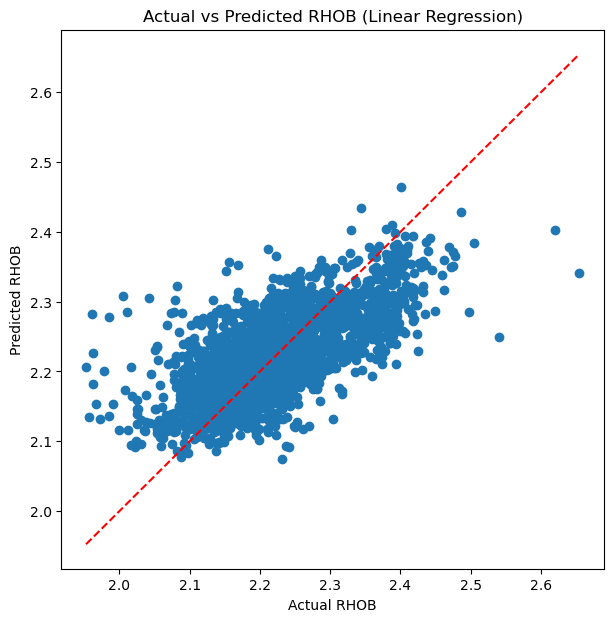

In [27]:
#  ACTUAL vs PREDICTED plot
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_line)
plt.title("Actual vs Predicted RHOB (Linear Regression)")
plt.xlabel("Actual RHOB")
plt.ylabel("Predicted RHOB")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', ls='--')
plt.show()

## INTEPRETATION

- The MAE and RMSE values are low relative to the RHOB range of 1.95–2.95 g/cc. Hence, indicating that the model predictions are close to actual values. In contrast, the R2 value of 0.446 tells us that the model explains only 44.6% of RHOB, predicting moderate performance. Implying that the model fails to understand the subsurface relationships.

- This implies that while the model captures general trends, it fails to fully represent the complexity of subsurface relationships.

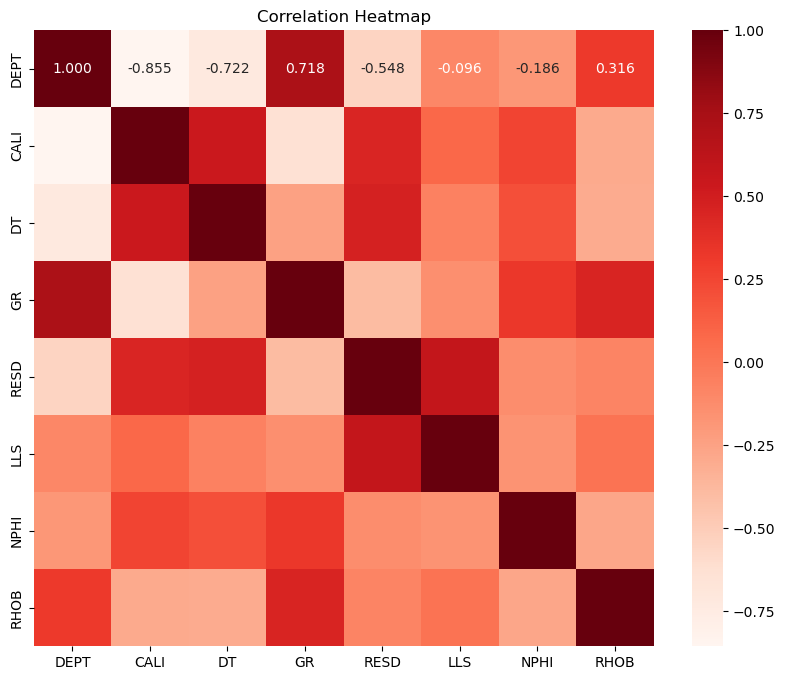

In [17]:
# heatmap
data_corr = working_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(data_corr, annot=True, cmap='Reds', fmt=".3f")
plt.title("Correlation Heatmap")
plt.show()

# Interactive

In [19]:
well = ls.read("datasets/Well_A.las")
well_df = well.df().replace(well.well.NULL.value, np.nan).reset_index()

In [20]:
working_df = well_df.copy()

`Archie = ((a/phi**m) / (rw/rt)) ** 1/n `

In [26]:
def update_well_model(a, m, rw, n):
    rt = working_df['RT']
    phi = working_df['POR']
    depth = working_df['DEPT']

    Sw = ((a/phi**m) * (rw/rt)) ** 1/n
    working_df['Sw_Calc'] = np.clip(Sw, 0, 1)

    # RQI
    gr_min = working_df['GR_NM'].min()
    gr_max = working_df['GR_NM'].max()
    working_df['GR_Norm'] = (working_df['GR_NM']-gr_min) / (gr_max - gr_min)
    working_df['RQI'] = working_df['POR'] * (1 - working_df['GR_Norm'])

    fig, ax = plt.subplots(1, 2, figsize=(10, 8), sharey=True)
    
    ax[0].plot(working_df['Sw_Calc'], depth, color='black', lw=0.5)
    ax[0].fill_betweenx(depth, 1, working_df['Sw_Calc'], color='green', alpha = 0.5, label="hydrocarbons") # for hydrocarbons
    ax[0].fill_betweenx(depth, working_df['Sw_Calc'],0,  color='blue', alpha = 0.7, label="water") # for water
    ax[0].set_title(f"Dynamic Sw \n (rw={rw}, a={a}, m={m}, n ={n})")
    ax[0].set_xlabel('Water Saturation')
    ax[0].set_xlim(1, 0)
    ax[0].legend()

    ax[1].fill_betweenx(depth, 0, working_df["RQI"], color="gold")
    ax[1].set_xlim(0, working_df["RQI"].max())
    ax[1].set_title("RQI")
    
    plt.gca().invert_yaxis()
    plt.show()

widgets.interact(update_well_model,
               rw = widgets.FloatSlider(value=0.55, min=0.05, max=1.16, steps=0.01, description='Rw'),
               a = widgets.FloatSlider(value=1.0, min=0.5, max=1.5, steps=0.05, description='a'),
               m = widgets.FloatSlider(value=2.0, min=1.3, max=3, steps=0.05, description='m'),
               n = widgets.FloatSlider(value=2.0, min=1.8, max=2.2, steps=0.1, description='n'),
               )

interactive(children=(FloatSlider(value=1.0, description='a', max=1.5, min=0.5), FloatSlider(value=2.0, descri…

<function __main__.update_well_model(a, m, rw, n)>